# Clustering

**Solución:** https://colab.research.google.com/drive/1ccFKhL9MGeIsgKIP8oNySU1aKYiJ_11j?usp=sharing

**Challenge:** https://colab.research.google.com/drive/1outX-txjrv_AnMeY_uda9DIjRiSRMPol?usp=sharing

"If intelligence was a cake, unsupervised learning would be the cake, supervised learning would be the icing on the cake, and reinforcement learning would be the cherry on the cake" - Yann LeCun

Análisis de Agrupamientos: Proceso de particionamiento de un conjunto de datos (u observaciones) en subconjuntos. Cada subconjunto es un grupo o cluster.

* Los datos en un mismo cluster deben ser similares entre sí.
* Los datos de diferentes clusters deben ser diferentes entre sí.

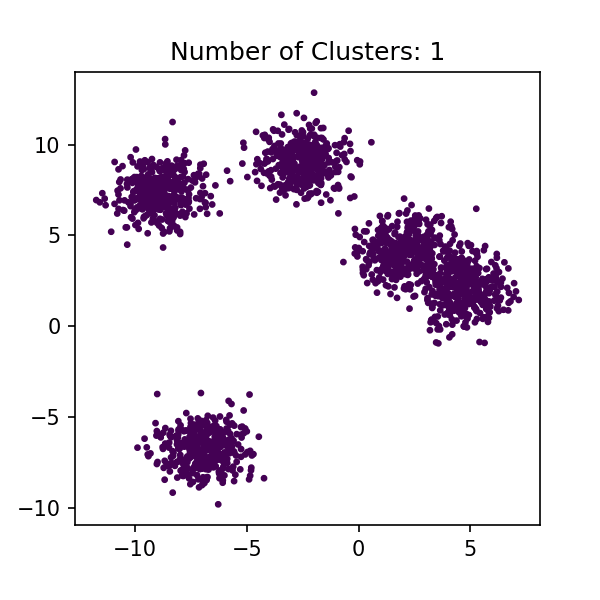

## K-Means

* Método que permite crear __clusters__ a partir de __datos numéricos__. El input del sistema son las mediciones numéricas de interés y los outputs son:
    * los centroides de los __clusters__ resultantes
    * la asignación de cada dato a un __cluster__ determinado.

* El __centroide__ es el punto que se encuentra en el centro de un __cluster__, (es la media de las coordenadas de todos los puntos de ese __cluster__).

* El número de centroides `k` es definido según convenga, para definir la distancia entre puntos y entre centroides se suele utilizar la distancia euclídea.

* La __inercia__ del modelo es la métrica de rendimiento usada para saber donde colocar mejor los centroides, la inercia del modelo es la
distancia media cuadrática entre cada observación y su centroide más cercano.

La Inercia o __Within sum of squares__ se obtiene:

$WSS = \sum_{i = 1}^{K}\sum_{j = 1}^{n_i}{\mid x_{ij} - c_i\mid}^2$

donde:

- $K$, es el número de centroides
- $n_i$, es el número de elementos que pertenecen al centroide $i$
- $c_i$, centroide del cluster $i$
- $x_{ij}$, elemento $j$ del cluster $i$

### Implementación en Scikit-learn

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn import datasets

from pprint import pprint

In [3]:
iris_dat = datasets.load_iris()
# pprint(iris_dat)
iris = (pd.DataFrame(iris_dat.data)
       .rename(columns={0:'sepal_length', 1:'sepal_width', 2:'petal_length', 3:'petal_width'})
       .assign(species=iris_dat.target))

iris.head(20)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


#### Inspección visual (ternary plot)

In [4]:
import plotly.express as px
fig = px.scatter_ternary(iris,
                         a="sepal_length",
                         b="petal_length",
                         c="sepal_width",
                         size="petal_width",
                         size_max=12,
                         color="petal_width")
fig.show()

### Seleccionamos el numero de clusters

In [5]:
X = iris.drop('species', axis=1)
y = iris['species']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state=42, stratify=y)

#### `n_clusters`

De forma arbitraria seleccionamos el valor del hiperparametro `n_clusters=3`

In [7]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=3)
model.fit(X_train)

KMeans(n_clusters=3)

#### `inertia_`

Obtenemos la inercia del modelo

In [8]:
model.inertia_

55.37218481518482

También puede ser obtenido en su formato negativo bajo el protocolo de sklearn dónde "entre mas grande mejor"

In [9]:
model.score(X_train)

-55.37218481518482

#### `cluster_centers_`

In [10]:
model.cluster_centers_

array([[4.98857143, 3.42571429, 1.48571429, 0.24      ],
       [5.925     , 2.70909091, 4.39545455, 1.43863636],
       [6.97692308, 3.14230769, 5.84615385, 2.11153846]])

Obtenemos los centroides

In [11]:
centroides_df = (pd.DataFrame(model.cluster_centers_)
                 .rename(columns={0:'sepal_length', 1:'sepal_width', 2:'petal_length', 3:'petal_width'})
)

In [12]:
centroides_df

,sepal_length,sepal_width,petal_length,petal_width
0,4.988571,3.425714,1.485714,0.240000
1,5.925000,2.709091,4.395455,1.438636
2,6.976923,3.142308,5.846154,2.111538


In [13]:
fig = px.scatter_ternary(centroides_df,
                         a="sepal_length",
                         b="petal_length",
                         c="sepal_width")
fig

In [14]:
model.get_params(deep=True)

{'algorithm': 'lloyd',
 'copy_x': True,
 'init': 'k-means++',
 'max_iter': 300,
 'n_clusters': 3,
 'n_init': 'auto',
 'random_state': None,
 'tol': 0.0001,
 'verbose': 0}

In [15]:
model.get_metadata_routing()

{'fit': {'sample_weight': None}, 'score': {'sample_weight': None}}

### Agregamos nuevas observaciones a nuestros clusters

a __K-MEANS__ todo lo que importa al asignar una observación
a un cluster es la distancia al centroide.

In [16]:
X_test

,sepal_length,sepal_width,petal_length,petal_width
107,7.3,2.9,6.3,1.8
63,6.1,2.9,4.7,1.4
133,6.3,2.8,5.1,1.5
56,6.3,3.3,4.7,1.6
127,6.1,3.0,4.9,1.8
140,6.7,3.1,5.6,2.4
53,5.5,2.3,4.0,1.3
69,5.6,2.5,3.9,1.1
20,5.4,3.4,1.7,0.2
141,6.9,3.1,5.1,2.3


In [17]:
labels = model.predict(X_test)
labels

array([2, 1, 1, 1, 1, 2, 1, 1, 0, 2, 0, 0, 2, 2, 0, 2, 1, 0, 0, 0, 1, 0,
       1, 2, 1, 1, 1, 1, 1, 0, 1, 2, 1, 0, 2, 0, 0, 0, 0, 2, 1, 0, 1, 2,
       1], dtype=int32)

In [18]:
X_test['cluster'] = labels
X_test

,sepal_length,sepal_width,petal_length,petal_width,cluster
107,7.3,2.9,6.3,1.8,2
63,6.1,2.9,4.7,1.4,1
133,6.3,2.8,5.1,1.5,1
56,6.3,3.3,4.7,1.6,1
127,6.1,3.0,4.9,1.8,1
140,6.7,3.1,5.6,2.4,2
53,5.5,2.3,4.0,1.3,1
69,5.6,2.5,3.9,1.1,1
20,5.4,3.4,1.7,0.2,0
141,6.9,3.1,5.1,2.3,2


In [19]:
pd.pivot_table(X_test, index='cluster')

,petal_length,petal_width,sepal_length,sepal_width
cluster,,,,
0,1.406667,0.260000,5.046667,3.433333
1,4.452632,1.421053,5.857895,2.831579
2,5.509091,2.036364,6.618182,2.954545


### Número optimo de clusters

#### Regla del codo

En general, no es fácil establecer el `k` optimo a priori y elegir el modelo con la menor inercia no es una buena idea ya que está regularmente disminuye a medida que aumentamos k, entonces La inercia no es una buena métrica de rendimiento.

In [20]:
inertias = {k: KMeans(n_clusters=k).fit(X_train).inertia_ for k in range(1, 13)}
inertias

{1: 493.0771428571429,
 2: 116.32567632850245,
 3: 55.37572063492063,
 4: 39.41772944457917,
 5: 33.68107380631065,
 6: 26.122741216678055,
 7: 23.870341837796076,
 8: 22.48282148999951,
 9: 23.580170634920638,
 10: 17.717441938178776,
 11: 17.75768731431967,
 12: 14.36789850427351}

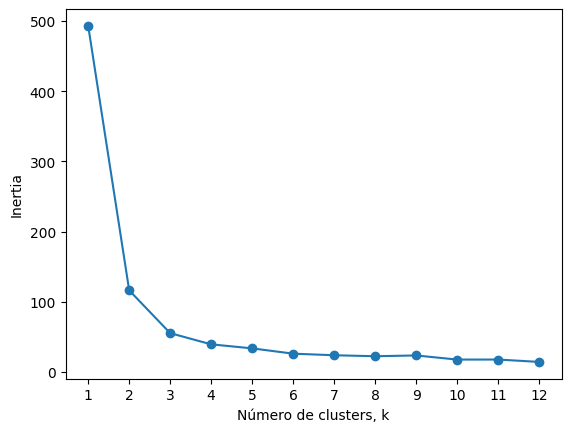

In [21]:
plt.plot(list(inertias.keys()),
         list(inertias.values()), '-o')
plt.xlabel('Número de clusters, k')
plt.ylabel('Inertia')
plt.xticks(list(inertias.keys()))
plt.show()

A medida que aumentamos k, la inercia cae muy rápid. Esta curva tiene aproximadamente la forma de un brazo, y hay un "codo" en k = 3.

__SI NO TUVIERAMOS MAS CONOCIMIENTO DE LOS DATOS k = 3 SERíA UNA BUENA OPCIÓN__

* Cualquier valor antes del codo sería dramático
* Cualquier valor despues del codo no ayudaría mucho, ya que podríamos simplemente estar dividiendo grupos perfectamente buenos por la mitad sin una buena razón.

Entonces, __si no hay información que ayude a tomar una mejor decisión, el valor del codo es la mejor opción__.

__NOTA__: En general este proceso no es sencillo y hay que tener en cuenta que K-Means es muy sensible a diferencias en las varianzas de las variables y a variables con escalas muy distintas.

#### Silhouette

* Un enfoque más preciso (pero también computacionalmente más costoso) es utilizar el __Silhouette score__.

* El __Silhouette score__ es el silhouette medio sobre todas las instancias.

* El Silhouette de una instancia se define cómo $\frac{b-a}{max(a, b)}$ dónde:
    * $a$ es la distancia media a otras instancias en el mismo cluster (la distancia intra cluster media)
    * $b$ es la media de la distancia al cluster mas cercano (la distancia media a las instancias del siguiente cluster, definida como la que minimiza a $b$, excluyendo la distancia del propio cluster)

* El coeficiente Silouette está entre -1 y 1 esto se interpreta:
    * Entre mas cerca está de 1, significa que la instancia está bien dentro de su cluster y lejos de otros clusters
    * Entre mas cerca está de 0, significa que está muy cerca de una frontera entre clusters
    * Entre mas cerca está de -1 significa que la instancia ha sido asignada a un cluster donde no corresponde

##### Silhouette scores

In [22]:
from sklearn.metrics import silhouette_score

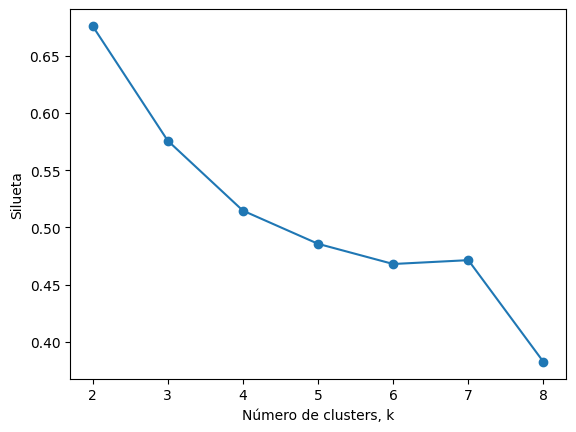

In [23]:
silhouettes = {k: silhouette_score(X_train, KMeans(n_clusters=k).fit_predict(X_train)) for k in range(2, 9)}

plt.plot(list(silhouettes.keys()),
         list(silhouettes.values()), '-o')
plt.xlabel('Número de clusters, k')
plt.ylabel('Silueta')
plt.xticks(list(silhouettes.keys()))
plt.show()

Está visualización es mas informativa que la gráfica del codo, en esta visualización observamos que `k=2` es un excelente `k`, pero `k=3` también es una excelente opción, estas opciones son mucho mejores que el resto, esta gráfica puede llegar a ser mas informativa que solo comparar inercias.

##### Silhouette diagrama

Una visualización aun mas informativa se obtiene cuando gráficamos el silhouette de cada instancia, agrupada por los clusters que los contiene y ordenada por sus valores.

Cada diagrama tiene forma de cuchillo por cluster:
* La altura del cuchillo significa la cantidad de instancias que contiene el cluster
* El ancho representa los coeficientes silhouette ordenados en el cluster (entre mas ancho mejor)
* La linea punteada representa el coeficiente silhouette medio

For n_clusters = 2, the average silhouette_score is: 0.6761
For n_clusters = 3, the average silhouette_score is: 0.5758
For n_clusters = 4, the average silhouette_score is: 0.5146
For n_clusters = 5, the average silhouette_score is: 0.4089
For n_clusters = 6, the average silhouette_score is: 0.3977
For n_clusters = 7, the average silhouette_score is: 0.3980
For n_clusters = 8, the average silhouette_score is: 0.3463


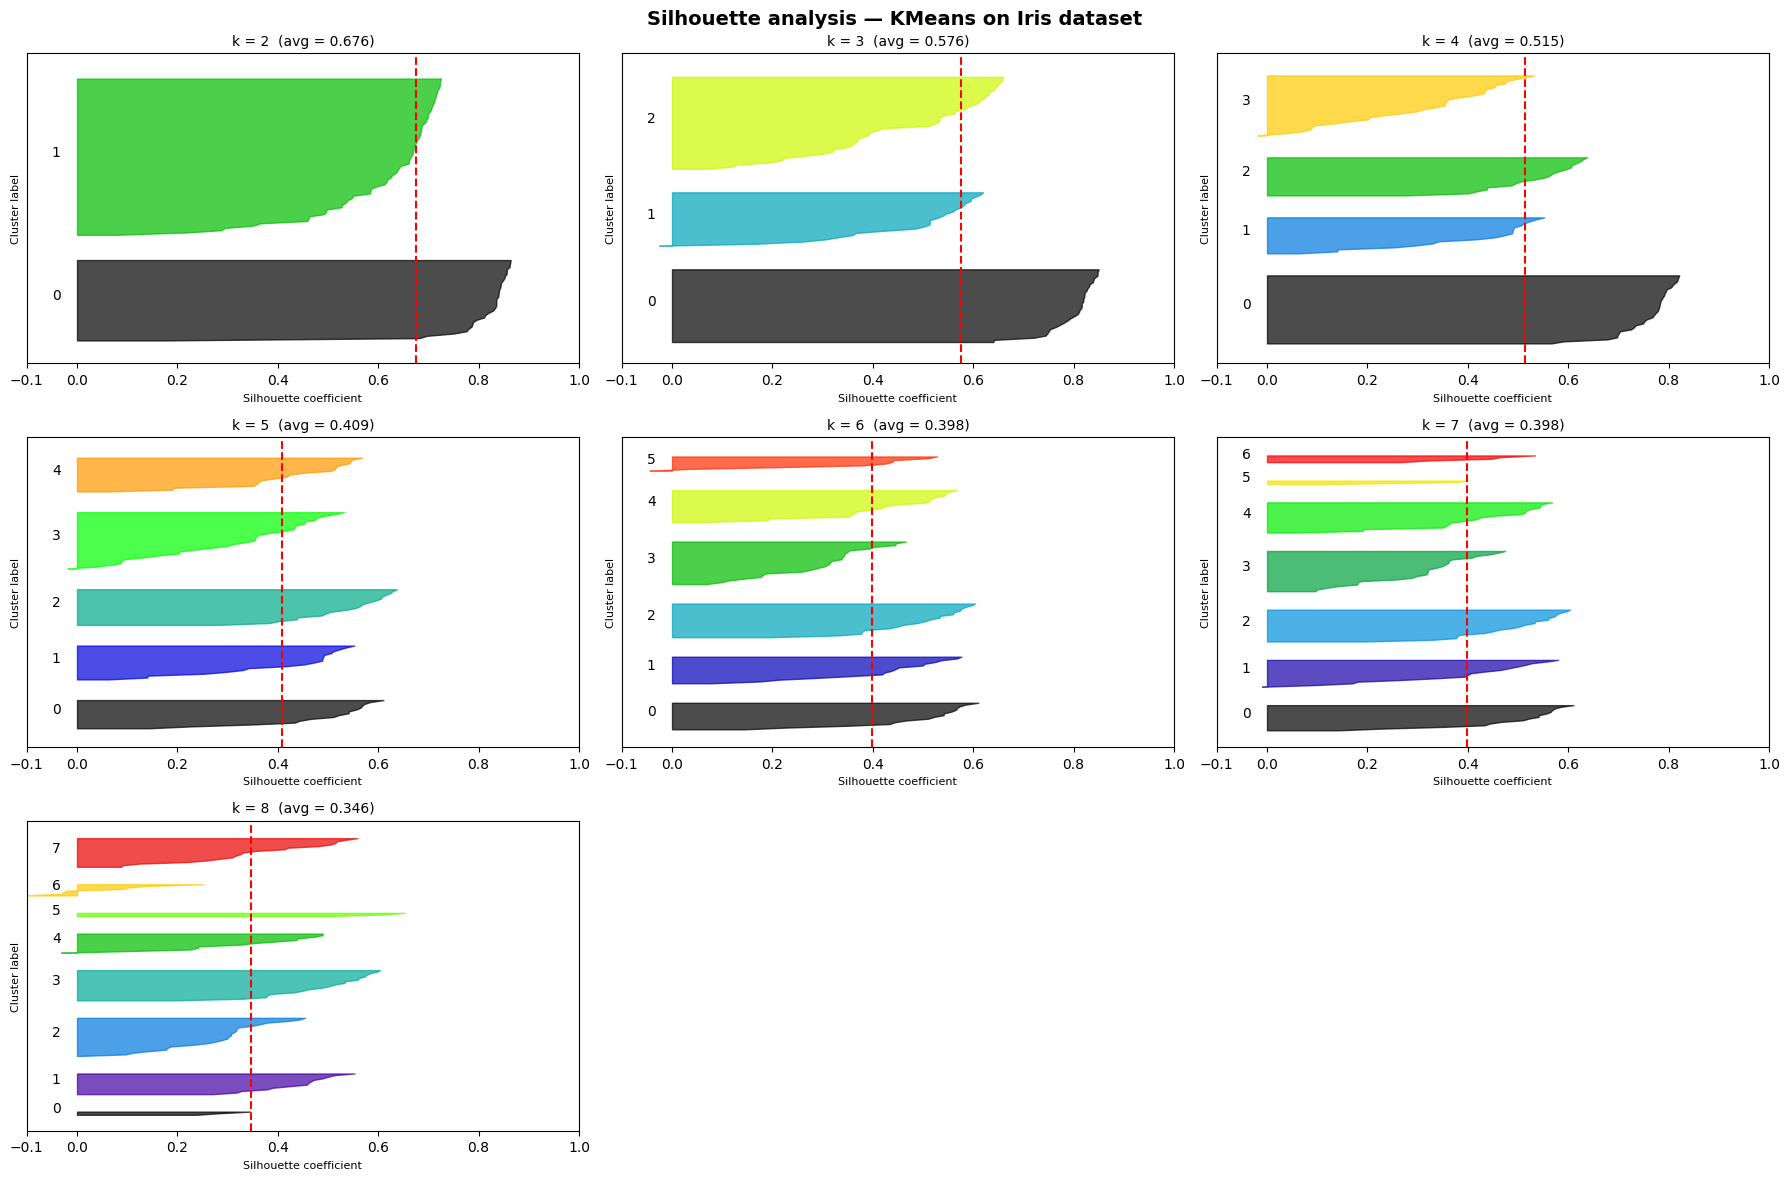

In [24]:
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np

n_clusters_range = range(2, 9)
n_plots = len(n_clusters_range)
cols = 3
rows = (n_plots + cols - 1) // cols  # ceil division

fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4))
axes = axes.flatten()

for idx, k in enumerate(n_clusters_range):
    ax = axes[idx]

    ax.set_xlim([-0.1, 1])
    ax.set_ylim([0, len(X_train) + (k + 1) * 10])

    clusterer = KMeans(n_clusters=k, random_state=10, n_init='auto')
    cluster_labels = clusterer.fit_predict(X_train)

    silhouette_avg = silhouette_score(X_train, cluster_labels)
    print(f"For n_clusters = {k}, the average silhouette_score is: {silhouette_avg:.4f}")

    sample_silhouette_values = silhouette_samples(X_train, cluster_labels)

    y_lower = 10
    for i in range(k):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / k)
        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax.set_title(f"k = {k}  (avg = {silhouette_avg:.3f})", fontsize=10)
    ax.set_xlabel("Silhouette coefficient", fontsize=8)
    ax.set_ylabel("Cluster label", fontsize=8)
    ax.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax.set_yticks([])
    ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

# Ocultar subplots sobrantes (si el total no es múltiplo de cols)
for idx in range(n_plots, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("Silhouette analysis — KMeans on Iris dataset", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

#### Recomendaciones para K-means

* Normalizar las variables antes de hacer K-means, restar a cada variable su media y dividirla por la desviación típica

## Challenge

Considera los datos creditcard.csv. Los puedes encontrar [aquí](https://drive.google.com/file/d/1jqZ6--OOGk477xv_yxqyell8RBtlOXL8/view?usp=drive_link)

Como contexto, estos datos fueron obtenidos del siguiente enlace: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

Consejo: Lee atentamente la descripción del dataset y el significado de las columnas en el enlace anterior.

## Realiza lo siguiente
1. Entrena un modelo con KMeans, recuerda separar la columna objetivo `Class` del resto de las columnas.
2. Identifica la mejor K utilizando el método del codo y el método de las siluetas.
3. Añade una columna llamada `cluster` etiquetando el set de prueba (30% de los datos).
4. Identifica el grupo al que pertenecen los datos cuyo `Class` es igual a 1. ¿Pertenecen a un solo grupo o a varios?

In [38]:
# Exportamos datos de archivos
df = pd.read_csv('creditcard.csv')
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [45]:
# Dataframe size
df.shape[0]

284807

In [64]:
# Separacion de la base en atributos
# Se consideran unicamente 20% de los datos pues se tardaba demasiado en mi colab

lim = int(np.round(np.array(df.shape[0])*0.2))# Corrected: df.shape[0] instead of df.shape(0)
print(f'Tamaño del arreglo {lim}')


X = df.iloc[:lim,0:13]
y = df['Class'].iloc[:lim]



Tamaño del arreglo 56961


In [65]:
# Exportar modelo
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state=42, stratify=y)

In [66]:
(len(X_train), len(X_test))

(39872, 17089)

In [67]:
# Se construyen las equivalencias

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))
scaler.fit(X_train) # Se contruyen las equivalencias
# 7.3 --> 1, 5.0 --> 0, 6.1 --> 0.5

MinMaxScaler()

In [68]:
# Se reescalan las variables

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)
X_test

# Comprobando normalización
print(X_train.min(), X_train.max(), 'Normalización correcta...')

0.0 1.0 Normalización correcta...


In [69]:
# Importacion del clasificador y memorización de los datos de training

from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors=11)
classifier.fit(X_train, y_train)

# Uso del modelo clasificador

y_pred = classifier.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [70]:
y_pred = classifier.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

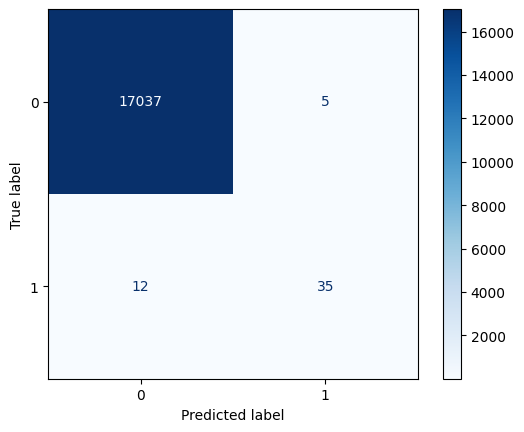

In [71]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class_names = ['0','1']
normalize = None
ConfusionMatrixDisplay.from_estimator(
        classifier,
        X_test,
        y_test, # Changed from X_test to y_test
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
plt.show() # Added to ensure the plot is displayed

In [74]:
# Reporte de clasificación

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17042
           1       0.88      0.74      0.80        47

    accuracy                           1.00     17089
   macro avg       0.94      0.87      0.90     17089
weighted avg       1.00      1.00      1.00     17089



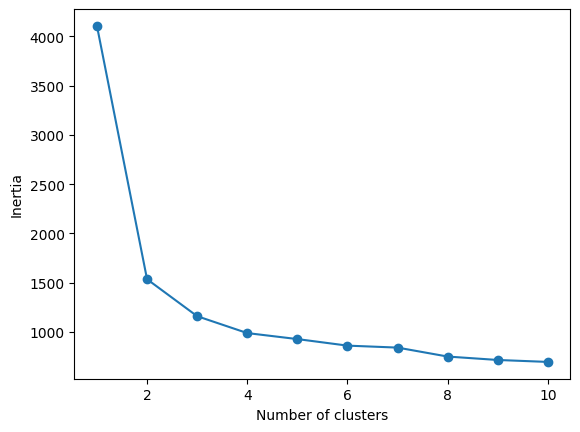

In [75]:
# Usamos el método de codo para hallar la mejor k

from sklearn.cluster import KMeans
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=10)
    kmeans.fit(X_train)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()



En este caso, con el método del codo, el mejor dato sería en k = 3.

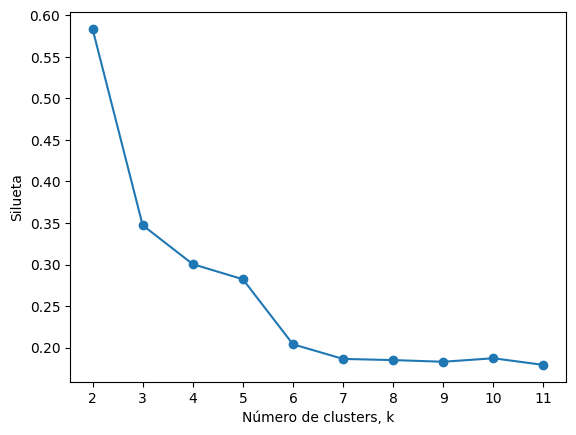

In [82]:
# Usamos el método de las siluetas


from sklearn.metrics import silhouette_score
silhouettes = {k: silhouette_score(X_train, KMeans(n_clusters=k).fit_predict(X_train)) for k in range(2, 12)}

plt.plot(list(silhouettes.keys()),
         list(silhouettes.values()), '-o')
plt.xlabel('Número de clusters, k')
plt.ylabel('Silueta')
plt.xticks(list(silhouettes.keys()))
plt.show()

In [83]:
# Añadir la columna cluster etiquetando el set de prueba.

from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=10)
kmeans.fit(X_train)
labels = kmeans.predict(X_test)

In [90]:
# Identificar el grupo al que pertenecen los datos cuyo Class es igual a 1

# Crear un DataFrame para analizar los resultados
results_df = X_test.copy()
# 'labels' comes from the KMeans prediction on X_test
results_df = pd.DataFrame(X_test, columns=df.columns[:13].tolist())
results_df['cluster'] = labels
results_df['true_class'] = y_test.values # Add true class labels from y_test

# Filtrar los datos donde la clase verdadera es 1
class_1_data = results_df[results_df['true_class'] == 1]

print("Clusters a los que pertenecen los datos con Class = 1:")
print(class_1_data['cluster'].value_counts())

# Determinar si pertenecen a un solo grupo o a varios
if len(class_1_data['cluster'].unique()) == 1:
    print(f"\nLos datos con Class = 1 pertenecen a un solo grupo: {class_1_data['cluster'].unique()[0]}")
else:
    print("\nLos datos con Class = 1 pertenecen a varios grupos.")


Clusters a los que pertenecen los datos con Class = 1:
cluster
2    21
0    16
1    10
Name: count, dtype: int64

Los datos con Class = 1 pertenecen a varios grupos.


For n_clusters = 2, the average silhouette_score is: 0.5835
For n_clusters = 3, the average silhouette_score is: 0.3472
For n_clusters = 4, the average silhouette_score is: 0.2990
For n_clusters = 5, the average silhouette_score is: 0.2823


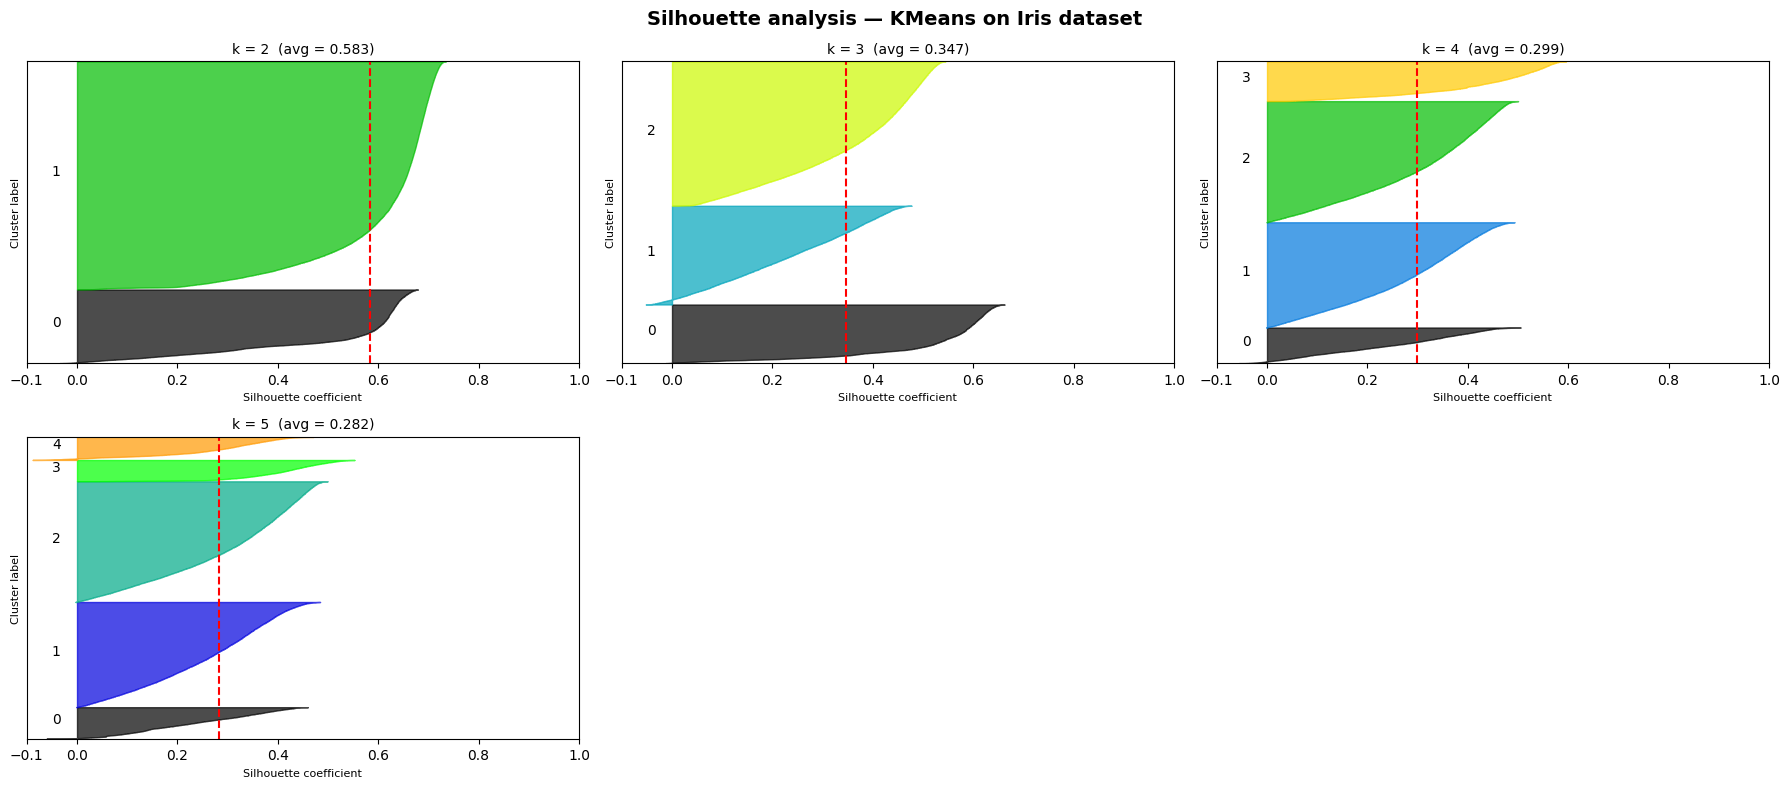

In [87]:
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np

n_clusters_range = range(2, 6)
n_plots = len(n_clusters_range)
cols = 3
rows = (n_plots + cols - 1) // cols  # ceil division

fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4))
axes = axes.flatten()

for idx, k in enumerate(n_clusters_range):
    ax = axes[idx]

    ax.set_xlim([-0.1, 1])
    ax.set_ylim([0, len(X_train) + (k + 1) * 10])

    clusterer = KMeans(n_clusters=k, random_state=10, n_init='auto')
    cluster_labels = clusterer.fit_predict(X_train)

    silhouette_avg = silhouette_score(X_train, cluster_labels)
    print(f"For n_clusters = {k}, the average silhouette_score is: {silhouette_avg:.4f}")

    sample_silhouette_values = silhouette_samples(X_train, cluster_labels)

    y_lower = 10
    for i in range(k):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / k)
        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax.set_title(f"k = {k}  (avg = {silhouette_avg:.3f})", fontsize=10)
    ax.set_xlabel("Silhouette coefficient", fontsize=8)
    ax.set_ylabel("Cluster label", fontsize=8)
    ax.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax.set_yticks([])
    ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

# Ocultar subplots sobrantes (si el total no es múltiplo de cols)
for idx in range(n_plots, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("Silhouette analysis — KMeans on Iris dataset", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()